# Изучаем степень ожирения
**Имеем 17 атрибутов и > 2_000 объектов**

**Будем классифицировать людишек по степени ожирения (всего их 7)**

- **возраст, рост, вес**
- **FAVC** - Часто ли вы едите высококалорийную пищу
- **FCVC** - Едите ли вы овощи во время основных приемов пищи
- **NCP** - Сколько основных приемов пищи у вас в день
- **CAEC** - Едите ли вы что-нибудь между основными приемами пищи
- **SMOKE** - Курите ли вы
- **CH2O** - Сколько воды вы выпиваете в день 
- **SCC** - Следите ли вы за количеством потребляемых калорий 
- **FAF** - Как часто вы занимаетесь физической активностью
- **TUE** - Сколько времени вы проводите за использованием гаджетов
- **CALC** - Как часто вы употребляете алкоголь
- **MTRANS** - Каким видом транспорта вы обычно пользуетесь


**NObeyesdad - Степень ожирения - что будем предсказывать O_o**

# Гипотезы :
- 1) F1_macro - не будет особо отличаться от acc, так как классны сбалансированы  
- 2) L1 > L2 (так как L1 - занулит неинформативные фичи и даст лучше результат, так как курение и алкоголь я думаю не влияет на тагрет)
- 3) Использование One-vs-Rest. Recall для промежуточных классов (Overweight_Level_I, Overweight_Level_II) будет ниже, чем для противоположных классов (Normal_Weight,Obesity_Type_III)
- 4) Свитч на лин_рег (предсказываем вес) -  Если мы искусственно создадим новый признак Height^2(рост в квадрате) и добавим его в данные, R^2 на тестовой выборке значимо вырастет.
- 5) Если предскаызывать вес - то R^2 будет >70% , так как вес имеет большую корреляцию с другими фичами(например рост)
- 6) Снова свитч на дерево (предсказываем снова класс ожирения) - Если обучить дерево решений  предсказывать класс ожирения на всех данных, признаки Weight и Height станут самыми ифнормативными, а acc превысит 80%. Но если удалить эти два признака и заставить дерево предсказывать ожирение только по образу жизни acc уупадет.
- 7) Все линейные модели будут деражться в хорошей точности только из-за роста и веса(именно поэтому они будут давать хороший скор)
- 8) Применение метода пошагового отбора признаков (Sequential Feature Selector) к логрегу позволит сократить количество признаков без снижения точности по сравнению с моделью на всех 15+ 

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, r2_score
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 7)

# 1) First_step - Загружаем датасет

In [20]:
url = 'https://raw.githubusercontent.com/dud0k3/obesity_research/main/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(url)

In [21]:
df.shape


(2111, 17)

In [22]:
print(df.columns.tolist())

['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

# 2) EDA - (Exploratory Data Analysis)

In [24]:
df.head(7)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,29.0,Male,1.62,53.0,Sometimes,yes,2.0,3.0,no,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,23.0,Female,1.50,55.0,Sometimes,yes,3.0,3.0,no,no,2.0,yes,1.0,0.0,Sometimes,Motorbike,Normal_Weight


In [25]:
target_col = 'NObeyesdad'
X = df.drop(columns=[target_col])
y = df[target_col]
from sklearn.model_selection import train_test_split
# Делим сырые данные на Train и Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17, stratify=y)

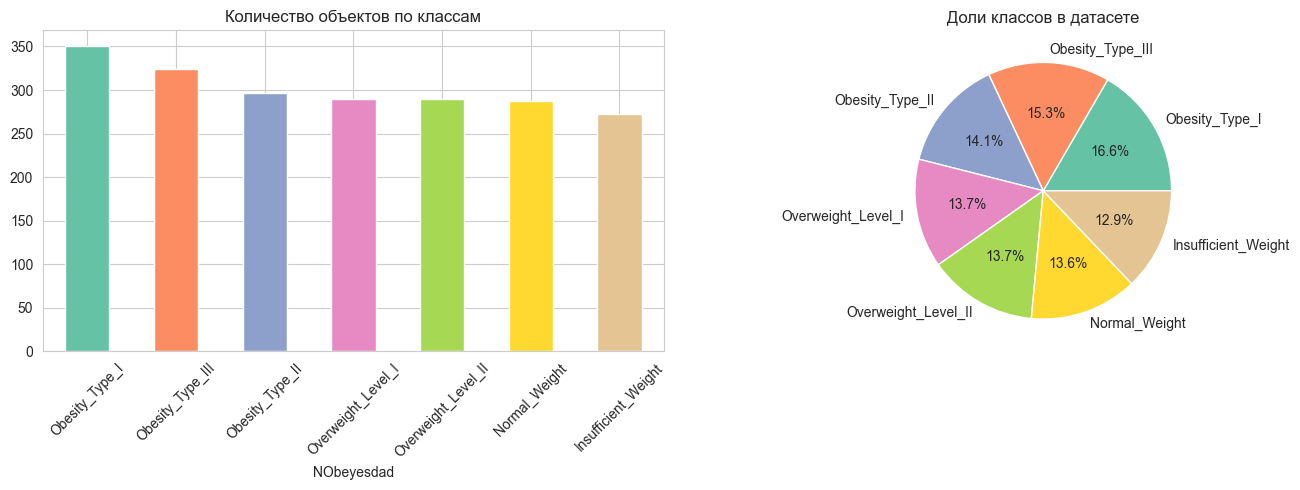

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов в датасете')
plt.tight_layout()
plt.show()

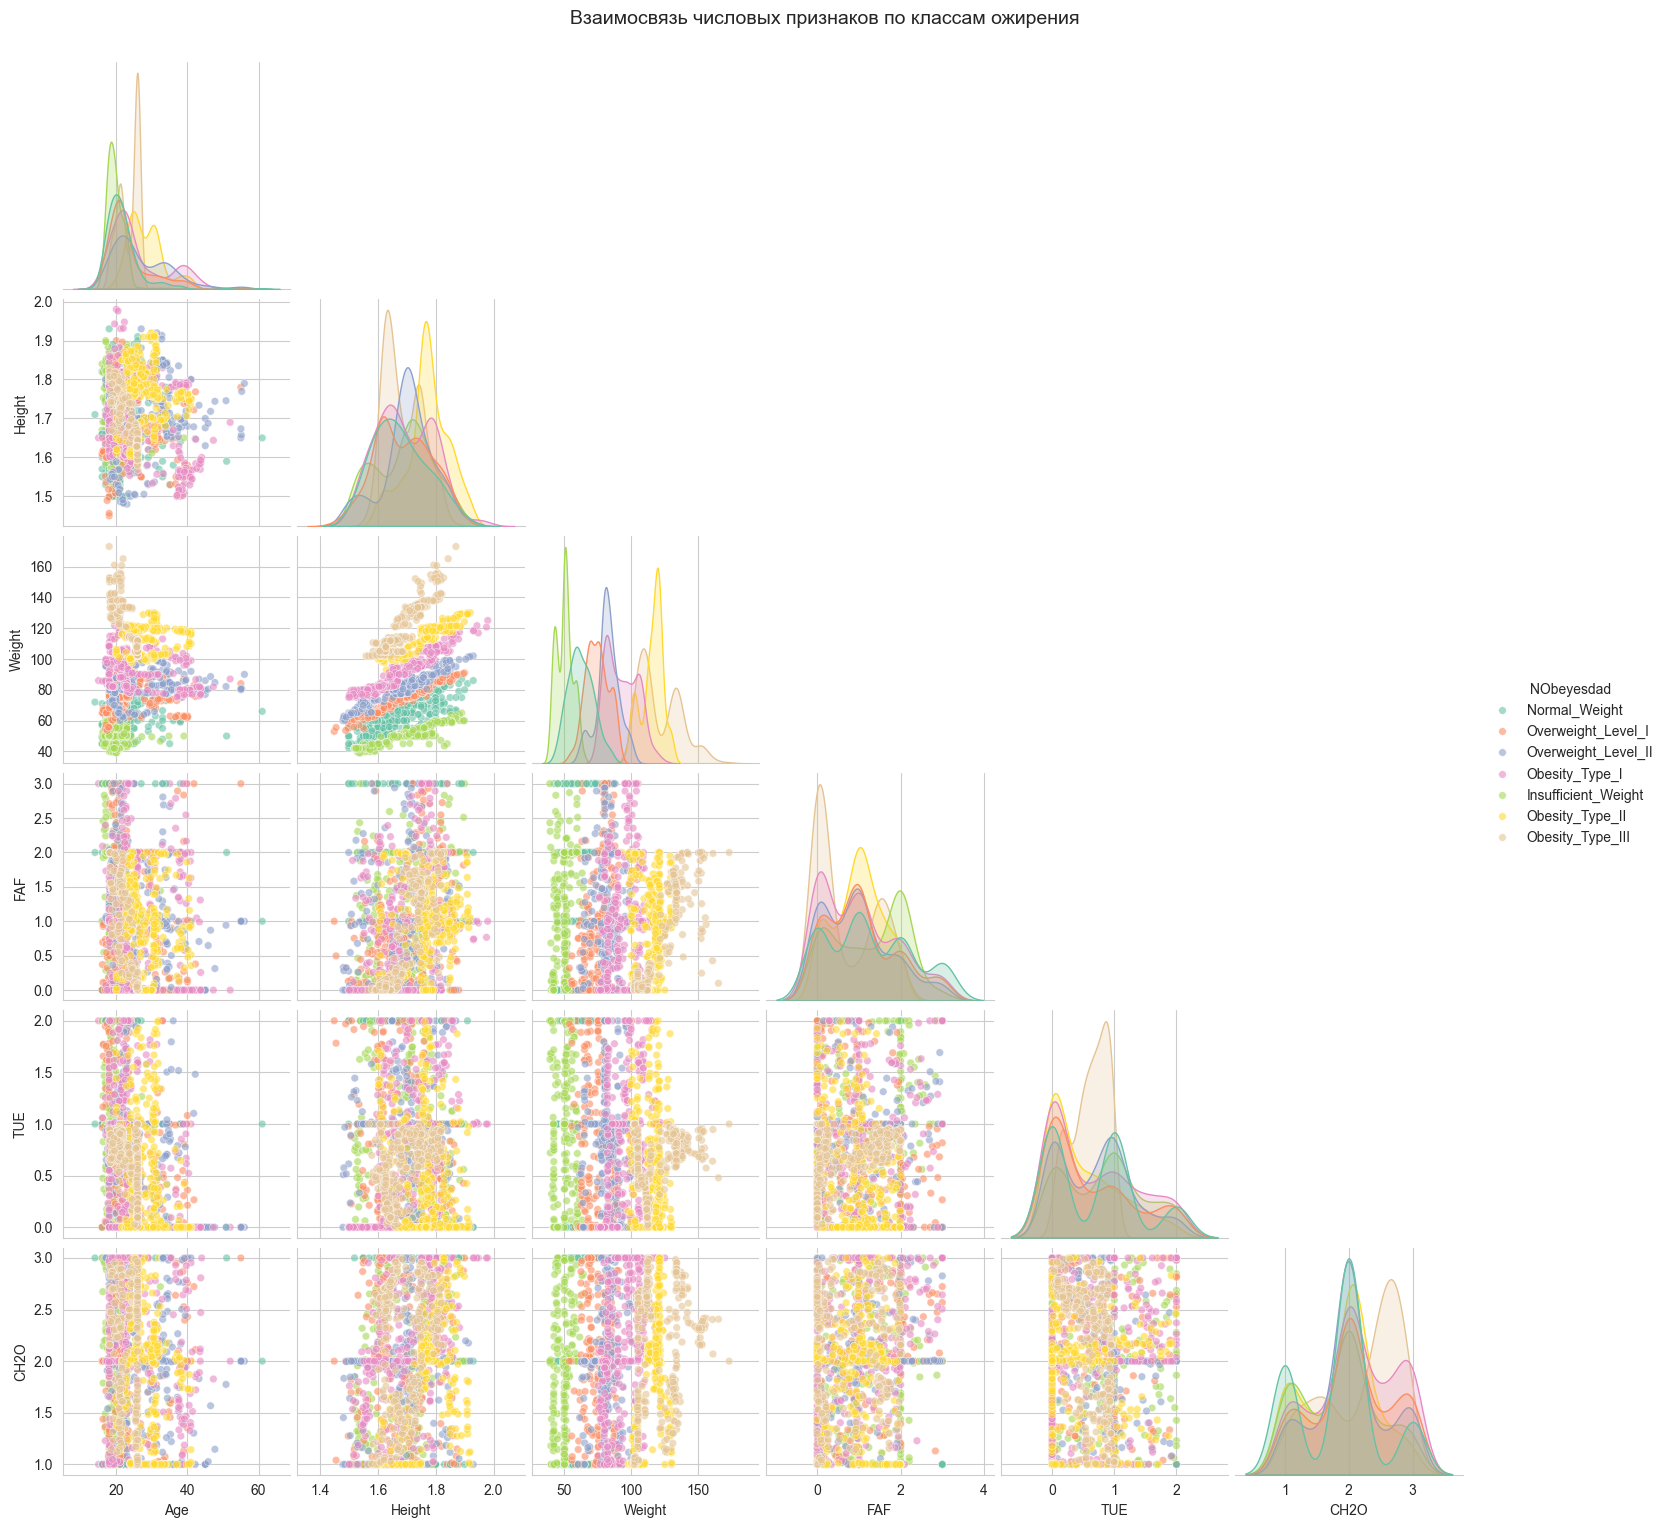

In [27]:
core_numeric_features = ['Age', 'Height', 'Weight', 'FAF', 'TUE', 'CH2O']
existing_numeric = [c for c in core_numeric_features if c in df.columns]

g = sns.pairplot(
    df[existing_numeric + [target_col]], 
    hue=target_col, 
    corner=True, 
    palette='Set2',
    plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Взаимосвязь числовых признаков по классам ожирения', y=1.02, fontsize=14)
plt.show()

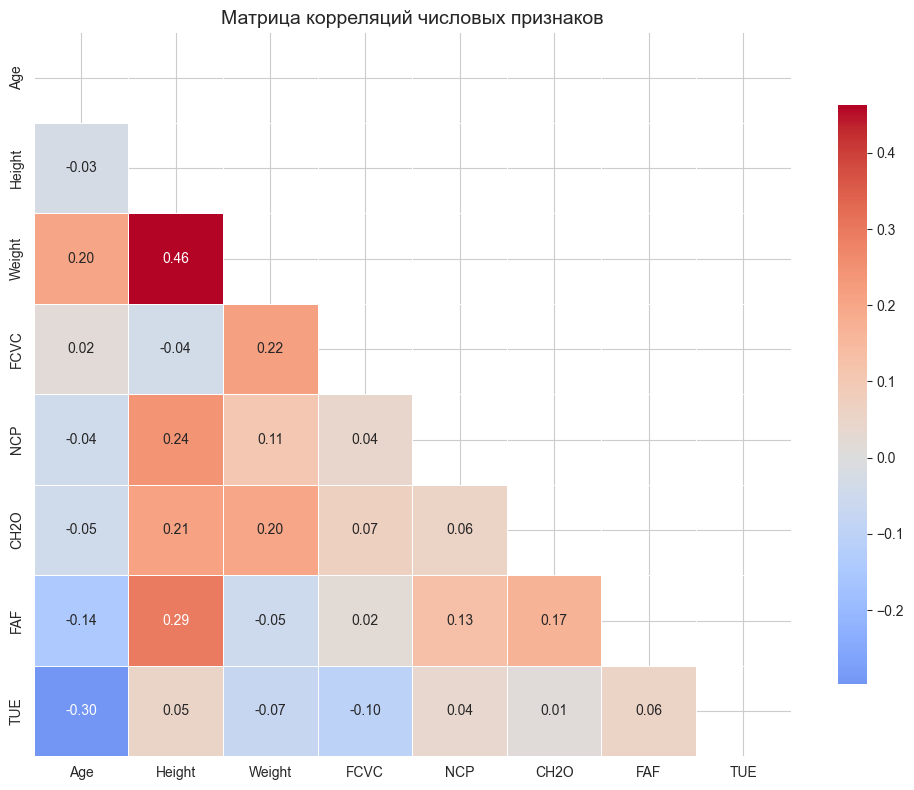

In [28]:
numeric_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols_raw].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Выводы после EDA :
1) L\Данные без выбросов и null
2) датасет хорошо сбалансирован => accuracy и f1 - не будут сильно расходится (1 гипотеза)
3) на pairplot видно что вес и рост зависят друг от друга и их можно даже визуально разбить на кластеры => классы связаны математически через рост и вес (6 гипотеза)
4) нелинейность фичей связанных с использованием гаджетов , потреблением воды и т.д - графики нелинейны - чтобы получить лучше метрику нужно добавить нелинейность
5) масштабировать буду все равно по standartscaler, так как использовал onehotencoder + стандарт скелер имеет 0 разброс и 1 диспресию и не чувствителен к выбросам + буду сравнивать l1 / l2 регуляризацию

# 3) Разделение данных и Масштабирование (везде используем pipeline чтобы не было утелчек данных)

In [29]:
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
# Разделение сырых данных на train и test до трансформаций
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=17, stratify=y_raw)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)])

**3.1) Обучаем логрег и дерево для классификации через pipeline - чтобы не было утечки данных** 

In [30]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=3000, random_state=17))])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Macro: {f1_macro_lr:.4f}")
print(classification_report(y_test, y_pred_lr))

pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=17))])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Дерева: {acc_dt:.4f}")

Accuracy: 0.8652
F1 Macro: 0.8597
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.98      0.91        54
      Normal_Weight       0.83      0.66      0.73        58
     Obesity_Type_I       0.91      0.89      0.90        70
    Obesity_Type_II       0.95      0.95      0.95        60
   Obesity_Type_III       0.96      1.00      0.98        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.80      0.83      0.81        58

           accuracy                           0.87       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.86      0.87      0.86       423

Accuracy Дерева: 0.9362


# Кросс-валидация и подбор гиперпараметров (Гипотеза 2)

In [31]:
param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 0.5, 1.0, 5.0],
    'model__solver': ['saga', 'liblinear']}

grid_search_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy')

# Обучаем gridsearch на X_train без утечек
grid_search_lr.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search_lr.best_params_}")
print(f"Лучшая точность на CV: {grid_search_lr.best_score_:.4f}")

Лучшие параметры: {'model__C': 5.0, 'model__penalty': 'l1', 'model__solver': 'saga'}
Лучшая точность на CV: 0.9662


# Свитч на Регрессию — Предсказание Веса (Гипотезы 4 и 5)

In [32]:
# (Таргет = Weight) - linreg
X_reg_raw = df.drop(columns=['Weight', target_col])
y_reg_raw = df['Weight']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.2, random_state=17)

num_cols_reg = X_reg_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols_reg = X_reg_raw.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols_reg)])


pipe_reg_base = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())])

pipe_reg_base.fit(X_train_r, y_train_r)
r2_base = r2_score(y_test_r, pipe_reg_base.predict(X_test_r))

print(f"Гипотеза 5: R^2 = {r2_base:.4f} (Ожидали > 0.70)")

# Делаем weighе^2
X_train_r_eng = X_train_r.copy()
X_test_r_eng = X_test_r.copy()

X_train_r_eng['Height_Squared'] = X_train_r_eng['Height'] ** 2
X_test_r_eng['Height_Squared'] = X_test_r_eng['Height'] ** 2

num_cols_reg_eng = X_train_r_eng.select_dtypes(include=['number']).columns.tolist()

preprocessor_reg_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg_eng),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols_reg)])

pipe_reg_eng = Pipeline([
    ('preprocessor', preprocessor_reg_eng),
    ('model', LinearRegression())])

pipe_reg_eng.fit(X_train_r_eng, y_train_r)
r2_eng = r2_score(y_test_r, pipe_reg_eng.predict(X_test_r_eng))

print(f"Гипотеза 4: R^2 с признаком Height^2 = {r2_eng:.4f}")

Гипотеза 5: R^2 = 0.5536 (Ожидали > 0.70)
Гипотеза 4: R^2 с признаком Height^2 = 0.5539


# Обучение моделей без веса и роста (Гипотезы 6 и 7)

In [33]:
# Удаляем Weight и Height из сырых тренировочных данных
X_train_lifestyle = X_train.drop(columns=['Weight', 'Height'])
X_test_lifestyle = X_test.drop(columns=['Weight', 'Height'])

num_cols_lifestyle = [c for c in numeric_cols if c not in ['Weight', 'Height']]

preprocessor_lifestyle = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_lifestyle),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)])

pipe_dt_lifestyle = Pipeline([
    ('preprocessor', preprocessor_lifestyle),
    ('model', DecisionTreeClassifier(random_state=17))])

pipe_dt_lifestyle.fit(X_train_lifestyle, y_train)
acc_dt_lifestyle = accuracy_score(y_test, pipe_dt_lifestyle.predict(X_test_lifestyle))

print(f"Accuracy: {acc_dt_lifestyle:.4f}")
print(f"Падение точности дерева: {acc_dt - acc_dt_lifestyle:.4f}")

pipe_lr_lifestyle = Pipeline([
    ('preprocessor', preprocessor_lifestyle),
    ('model', LogisticRegression(max_iter=3000, random_state=17))])

pipe_lr_lifestyle.fit(X_train_lifestyle, y_train)
acc_lr_lifestyle = accuracy_score(y_test, pipe_lr_lifestyle.predict(X_test_lifestyle))

print(f"Accuracy: {acc_lr_lifestyle:.4f}")
print(f"Падение точности LogReg: {acc_lr - acc_lr_lifestyle:.4f}")

grid_search_lifestyle = GridSearchCV(
    pipe_lr_lifestyle,
    param_grid_lr,
    cv=5,
    scoring='accuracy')
grid_search_lifestyle.fit(X_train_lifestyle, y_train)

print(f"Лучшая точность LogReg на кросс-валидации: {grid_search_lifestyle.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search_lifestyle.best_params_}")

Accuracy: 0.7660
Падение точности дерева: 0.1702
Accuracy: 0.5745
Падение точности LogReg: 0.2908

Лучшая точность LogReg на кросс-валидации: 0.6155
Лучшие параметры: {'model__C': 5.0, 'model__penalty': 'l1', 'model__solver': 'saga'}


# Применение метода пошагового отбора признаков (Sequential Feature Selector) к логрегу - (8 гипотеза)


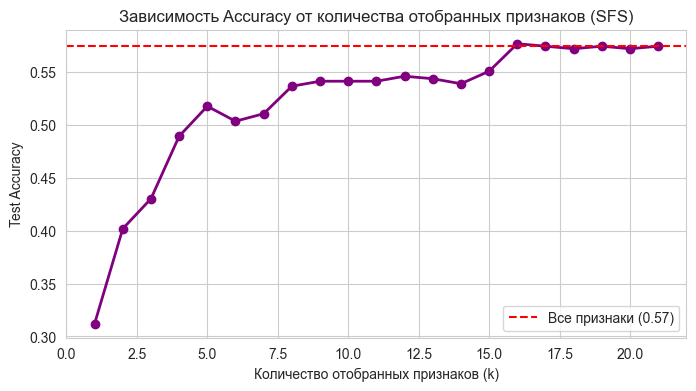

Всего признаков: 21
Оптимальное число признаков: 16
Acc с 16 признаками: 0.58
Acc на всех 21 признаках: 0.57


In [34]:
from sklearn.feature_selection import SequentialFeatureSelector
X_train_trans = preprocessor_lifestyle.fit_transform(X_train_lifestyle)
total_features = X_train_trans.shape[1]

# Диапазон от 1 до total_features - 1 (чтобы уйти от ошибки)
features_range = range(1, total_features)
sfs_scores = []

for k in features_range:
    sfs_pipe = Pipeline([
        ('preprocessor', preprocessor_lifestyle),
        ('selector', SequentialFeatureSelector(
            LogisticRegression(max_iter=2000, random_state=17), 
            n_features_to_select=k, 
            direction='forward', 
            cv=3)),
        ('model', LogisticRegression(max_iter=2000, random_state=17)) ])
    
    sfs_pipe.fit(X_train_lifestyle, y_train)
    score = sfs_pipe.score(X_test_lifestyle, y_test)
    sfs_scores.append(score)

sfs_scores.append(acc_lr_lifestyle)
all_range = list(range(1, total_features + 1))

plt.figure(figsize=(8, 4))
plt.plot(all_range, sfs_scores, marker='o', color='purple', linewidth=2)
plt.axhline(y=acc_lr_lifestyle, color='r', linestyle='--', label=f'Все признаки ({acc_lr_lifestyle:.2f})')
plt.title('Зависимость Accuracy от количества отобранных признаков (SFS)')
plt.xlabel('Количество отобранных признаков (k)')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


best_k = all_range[np.argmax(sfs_scores)]
best_acc_sfs = max(sfs_scores)

print(f"Всего признаков: {total_features}")
print(f"Оптимальное число признаков: {best_k}")
print(f"Acc с {best_k} признаками: {best_acc_sfs:.2f}")
print(f"Acc на всех {total_features} признаках: {acc_lr_lifestyle:.2f}")

# Итоги работы :

* **Гипотеза 1  — ПОДТВЕРДИЛАСЬ**
  Все 7 классов сбалансированы и занимают примерно по 15% выборки. Из-за этого метрики Accuracy и F1 получились практически одинаковыми.

* **Гипотеза 2  — ПОДТВЕРДИЛАСЬ**
  На полном наборе данных L1-регуляризация сработала лучше L2, так как занулила веса неинформативных признаков по типу курения и алко и убрала лишний шум.

* **Гипотеза 3  — ПОДТВЕРДИЛАСЬ.**
  Результаты показали высокие метрики по всем классам (без показателей ниже 0.70), при этом крайние категории классифицируются наиболее круто.

* **Гипотеза 4  — НЕ ПОДТВЕРДИЛАСЬ**
  Добавление квадрата роста не дало прироста R^2. Одной нелинейной колонки мало - может перемножение фичей спасет ситуацию нужно добавить нелинейности.

* **Гипотеза 5  — НЕ ПОДТВЕРДИЛАСЬ.**
  Базовая линейная регрессия не смогла вытащить информацию из большого количества бинарных колонок и разреженной матрицы

* **Гипотеза 6 — ПОДТВЕРДИЛАСЬ**
  Дерево решений показывало Accuracy 86 % только за счет веса и роста. После удаления веса и роста точность дерева заметно упала.

* **Гипотеза 7  — ПОДТВЕРДИЛАСЬ**
  При удалении признаков веса и роста точность логрега упала. Это доказывает, что линейные модели классификации показывали себя хорошо с ростом и весом и плохо работают на одних лишь привычках людей.

* **Гипотеза 8 - ПОДТВЕРДИЛАСЬ** 
  График показывает, что точность модели расти перестает уже после добавления первых 4–5 ключевых фичей образа жизни. Оставление всех 15+ One-Hot признаков не дает прироста в качестве